In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a = np.array([1, 2, 3, 4])              # từ list
b = np.zeros((3, 4))                    # ma trận 3×4 toàn 0
c = np.ones(5)                          # vector 5 phần tử toàn 1
d = np.arange(0, 10, 2)                 # 0, 2, 4, 6, 8
e = np.linspace(0, 1, 5)                # 5 số đều từ 0 đến 1
f = np.random.rand(3, 3)                # ma trận 3×3 phân phối đều
g = np.random.randn(2, 3)               # ma trận 2×3 phân phối chuẩn

print('a shape:', a.shape, ' dtype:', a.dtype)
print('b =\n', b)
print('e =', e)
print('f =\n', f)
print('g =\n', g)

a shape: (4,)  dtype: int64
b =
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
e = [0.   0.25 0.5  0.75 1.  ]
f =
 [[0.85466739 0.11011458 0.03029647]
 [0.65057313 0.22802425 0.58248678]
 [0.82969558 0.83026481 0.90417765]]
g =
 [[ 2.61245605e-01  5.61341389e-01 -2.87032686e+00]
 [ 1.78224898e-03 -1.16854337e-01  1.48706003e+00]]


Bài 1: NumPy cơ bản
Tạo mảng a = np.arange(20). Lấy ra các phần tử ở vị trí chẵn (0, 2, 4...).
Tạo ma trận 5×5 toàn số 0, sau đó đặt 1 trên đường chéo chính (gợi ý: np.eye hoặc gán bằng M[range(5), range(5)] = 1).
Cho M = np.random.randn(4, 5). Tính tổng theo từng hàng, theo từng cột. Kiểm tra shape kết quả có đúng (4,) và (5,) không.

In [6]:
a = np.arange(0,20,2)
print('a =', a)

a = [ 0  2  4  6  8 10 12 14 16 18]


In [8]:
b[range(5), range(5)] = 1
print('b =', b)

b = [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [12]:
M = np.random.randn(4, 5)
print('Tổng theo axis=0 (gộp hàng → 1 hàng):', M.sum(axis=0))
print('Tổng theo axis=1 (gộp cột → 1 cột):', M.sum(axis=1))
print('M shape:', M.sum(axis=0).shape)
print('M shape:', M.sum(axis=1).shape)

Tổng theo axis=0 (gộp hàng → 1 hàng): [ 0.02803057  0.24678097 -3.75400061 -1.72622757  3.50842723]
Tổng theo axis=1 (gộp cột → 1 cột): [ 0.26390891  2.02187961 -0.72795925 -3.25481869]
M shape: (5,)
M shape: (4,)


Bài 2: Broadcasting và normalize
Cho X = np.random.randn(100, 4) (100 mẫu, 4 đặc trưng). Hãy chuẩn hoá z-score theo cột: với mỗi cột, trừ trung bình rồi chia độ lệch chuẩn.

Gợi ý: X.mean(axis=0) shape (4,), dùng broadcasting để trừ đi.
Sau khi chuẩn hoá, X_normalized.mean(axis=0) phải gần 0, X_normalized.std(axis=0) phải gần 1.

In [17]:
X = np.random.randn(100, 4)
# Chuẩn hoá z-score: (X - mean) / std
X_normalized = (X - X.mean(axis=0)) / X.std(axis=0)

print('X_normalized.mean(axis=0) = ', X_normalized.mean(axis=0))
print('X_normalized.std(axis=0) = ', X_normalized.std(axis=0))

X_normalized.mean(axis=0) =  [ 4.44089210e-18  9.54791801e-17 -2.22044605e-18  4.21884749e-17]
X_normalized.std(axis=0) =  [1. 1. 1. 1.]


Bài 3: Pandas — phân tích Iris
Đọc file Iris.csv (trong thư mục 1. PyTorch/). Trả lời:

Có bao nhiêu dòng, bao nhiêu cột?
Trung bình sepal.length theo từng loài (variety) là bao nhiêu? (gợi ý: groupby)
Loài nào có petal.width lớn nhất?
Vẽ scatter plot 2D (sepal.length vs petal.length), tô màu theo loài.

Số dòng: 150, Số cột: 6

Trung bình SepalLengthCm theo loài:
 Species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: SepalLengthCm, dtype: float64

Loài có petal.width lớn nhất là: Iris-virginica (2.5)


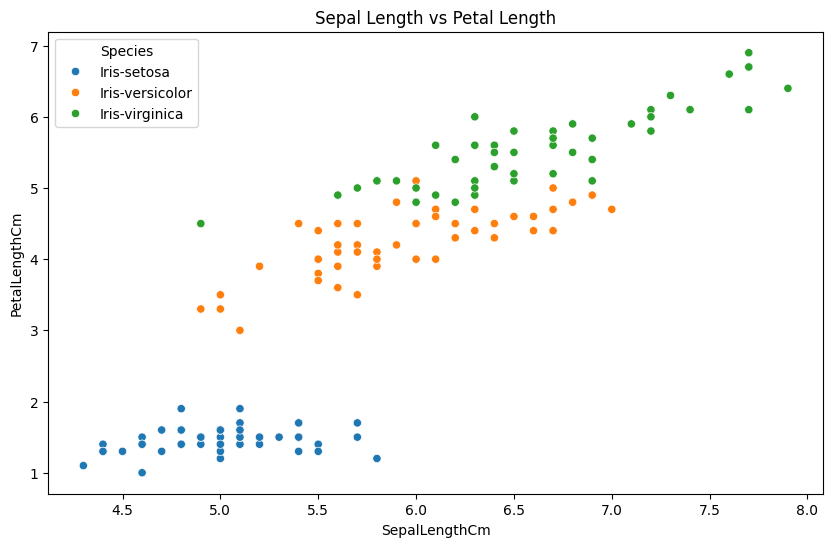

In [25]:
df = pd.read_csv('/content/Iris.csv')

print(f'Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}')

avg_sepal = df.groupby('Species')['SepalLengthCm'].mean()
print('\nTrung bình SepalLengthCm theo loài:\n', avg_sepal)

idx_max = df['PetalWidthCm'].idxmax()
max_species = df.loc[idx_max, 'Species']
max_val = df.loc[idx_max, 'PetalWidthCm']
print(f'\nLoài có petal.width lớn nhất là: {max_species} ({max_val})')

import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='SepalLengthCm', y='PetalLengthCm', hue='Species')
plt.title('Sepal Length vs Petal Length')
plt.show()

step  0: x = 0.6000, y = 10.0000
step  5: x = 2.2136, y = 1.9664
step 10: x = 2.7423, y = 1.1038
step 15: x = 2.9156, y = 1.0111
step 20: x = 2.9723, y = 1.0012
step 25: x = 2.9909, y = 1.0001
step 29: x = 2.9963, y = 1.0000


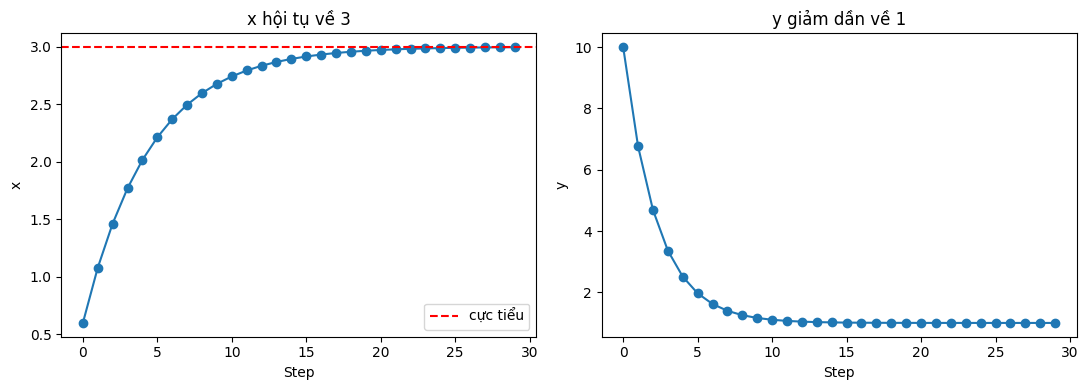

In [30]:
import torch
import matplotlib.pyplot as plt

x = torch.tensor(0.0, requires_grad=True)
lr = 0.1
history = []

for step in range(30):
    y = (x - 3)**2 + 1
    y.backward()

    # Cập nhật x bằng gradient descent.
    # `with torch.no_grad()` để tắt việc track autograd cho phép cập nhật này
    # — vì cập nhật trọng số không cần được đưa vào graph tính đạo hàm.
    with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()           # phải zero_grad sau khi cập nhật

    history.append((x.item(), y.item()))
    if step % 5 == 0 or step == 29:
        print(f'step {step:2d}: x = {x.item():.4f}, y = {y.item():.4f}')

xs, ys = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs, 'o-'); axes[0].axhline(3, color='red', linestyle='--', label='cực tiểu')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('x'); axes[0].legend(); axes[0].set_title('x hội tụ về 3')
axes[1].plot(ys, 'o-'); axes[1].set_xlabel('Step'); axes[1].set_ylabel('y'); axes[1].set_title('y giảm dần về 1')
plt.tight_layout(); plt.show()

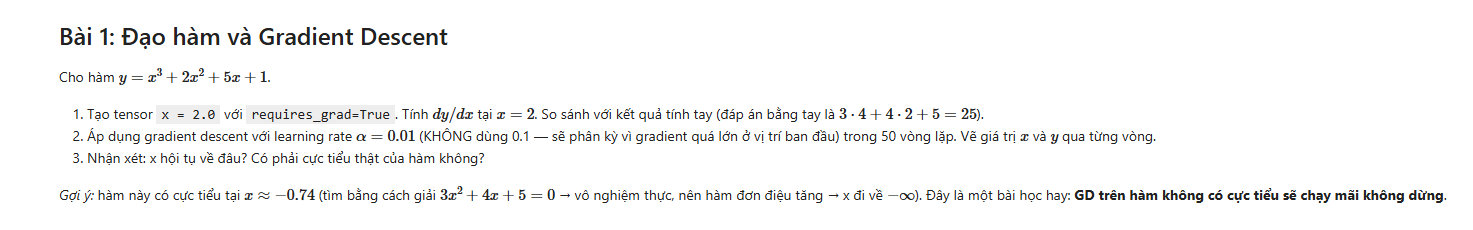

In [33]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x**2 + 5*x + 1
print(f'y = {y.item()}')
y.backward()
print(f'dy/dx tại x=2: {x.grad.item()}')

y = 27.0
dy/dx tại x=2: 25.0


step  0: x = -0.0400, y = 5.0000
step  5: x = -0.2068, y = 4.3848
step 10: x = -0.3291, y = 4.0535
step 15: x = -0.4190, y = 3.8750
step 20: x = -0.4849, y = 3.7789
step 25: x = -0.5332, y = 3.7271
step 30: x = -0.5687, y = 3.6992
step 35: x = -0.5948, y = 3.6842
step 40: x = -0.6139, y = 3.6761
step 45: x = -0.6280, y = 3.6718
step 49: x = -0.6364, y = 3.6698


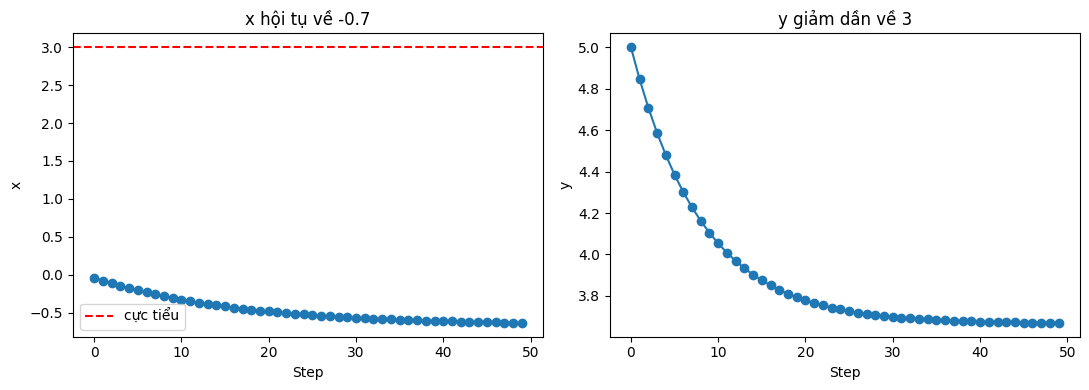

In [37]:
import matplotlib.pyplot as plt

x = torch.tensor(0.0, requires_grad=True)
lr = 0.01
history = []

for step in range(50):
    y = 3*x**2 + 4*x + 5
    y.backward()

    # Cập nhật x bằng gradient descent.
    # `with torch.no_grad()` để tắt việc track autograd cho phép cập nhật này
    # — vì cập nhật trọng số không cần được đưa vào graph tính đạo hàm.
    with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()           # phải zero_grad sau khi cập nhật

    history.append((x.item(), y.item()))
    if step % 5 == 0 or step == 49:
        print(f'step {step:2d}: x = {x.item():.4f}, y = {y.item():.4f}')

xs, ys = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs, 'o-'); axes[0].axhline(3, color='red', linestyle='--', label='cực tiểu')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('x'); axes[0].legend(); axes[0].set_title('x hội tụ về -0.7')
axes[1].plot(ys, 'o-'); axes[1].set_xlabel('Step'); axes[1].set_ylabel('y'); axes[1].set_title('y giảm dần về 3')
plt.tight_layout(); plt.show()

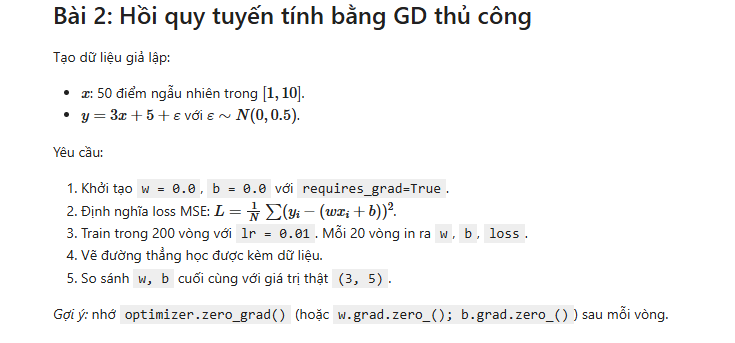

In [38]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
X = (10 - 1) * torch.rand(50, 1) + 1
y_true = 3 * X + 5 + torch.randn(50, 1) * 0.5

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

lr = 0.01

for epoch in range(201):
    y_pred = w * X + b
    loss = torch.mean((y_pred - y_true)**2)

    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        w.grad.zero_()
        b.grad.zero_()

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}: w={w.item():.3f}, b={b.item():.3f}, loss={loss.item():.4f}')

print(f'\nKết quả cuối cùng: w={w.item():.4f}, b={b.item():.4f}')
print(f'So sánh với giá trị thật (3, 5): Sai số w={abs(w.item()-3):.4f}, Sai số b={abs(b.item()-5):.4f}')

Epoch   0: w=3.189, b=0.465, loss=596.5239
Epoch  20: w=3.612, b=0.767, loss=2.6575
Epoch  40: w=3.580, b=0.991, loss=2.3999
Epoch  60: w=3.550, b=1.203, loss=2.1696
Epoch  80: w=3.521, b=1.403, loss=1.9636
Epoch 100: w=3.494, b=1.593, loss=1.7793
Epoch 120: w=3.469, b=1.772, loss=1.6145
Epoch 140: w=3.445, b=1.942, loss=1.4671
Epoch 160: w=3.422, b=2.103, loss=1.3352
Epoch 180: w=3.400, b=2.254, loss=1.2173
Epoch 200: w=3.380, b=2.398, loss=1.1118

Kết quả cuối cùng: w=3.3801, b=2.3978
So sánh với giá trị thật (3, 5): Sai số w=0.3801, Sai số b=2.6022


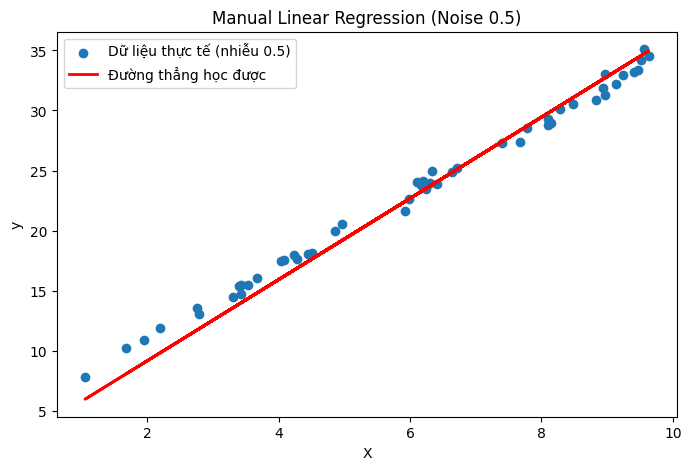

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y_true.numpy(), label='Dữ liệu thực tế (nhiễu 0.5)')
plt.plot(X.numpy(), (w * X + b).detach().numpy(), color='red', linewidth=2, label='Đường thẳng học được')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Manual Linear Regression (Noise 0.5)')
plt.show()

Bài 3: Tạo tensor với các phương thức khác nhau
Viết một cell tạo và in ra:

torch.empty(3, 4)
torch.zeros(2, 3)
torch.ones(4)
torch.rand(3, 3) — phân phối đều trong [0, 1]
torch.randn(3, 3) — phân phối chuẩn N(0, 1)
Tạo một tensor t có shape (2, 6) rồi dùng view và view_as để biến nó thành shape (3, 4) (gợi ý: view_as cần một tensor mẫu có shape mong muốn).

In [41]:
import torch

print("--- Khởi tạo Tensor ---")
print("torch.empty(3, 4):\n", torch.empty(3, 4))
print("\ntorch.zeros(2, 3):\n", torch.zeros(2, 3))
print("\ntorch.ones(4):\n", torch.ones(4))
print("\ntorch.rand(3, 3) (Uniform [0, 1]):\n", torch.rand(3, 3))
print("\ntorch.randn(3, 3) (Normal N(0, 1)):\n", torch.randn(3, 3))

print("\n--- Reshaping ---")
t = torch.arange(12).reshape(2, 6)
print(f"Tensor t ban đầu (shape {t.shape}):\n", t)

t_view = t.view(3, 4)
print(f"\nSau khi t.view(3, 4):\n", t_view)

template = torch.empty(3, 4)
t_view_as = t.view_as(template)
print(f"\nSau khi t.view_as(template) (với template shape 3, 4):\n", t_view_as)

--- Khởi tạo Tensor ---
torch.empty(3, 4):
 tensor([[4.4686e-16, 0.0000e+00, 2.7607e-19, 0.0000e+00],
        [1.1210e-43, 0.0000e+00, 8.9683e-44, 0.0000e+00],
        [2.0257e-19, 0.0000e+00, 1.1351e-43, 0.0000e+00]])

torch.zeros(2, 3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

torch.ones(4):
 tensor([1., 1., 1., 1.])

torch.rand(3, 3) (Uniform [0, 1]):
 tensor([[0.6044, 0.7581, 0.9037],
        [0.9555, 0.1035, 0.6258],
        [0.2849, 0.4452, 0.1258]])

torch.randn(3, 3) (Normal N(0, 1)):
 tensor([[-0.3555, -0.3380, -0.4270],
        [-0.4377,  1.3522, -1.5015],
        [-0.1378,  1.0448,  1.8319]])

--- Reshaping ---
Tensor t ban đầu (shape torch.Size([2, 6])):
 tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

Sau khi t.view(3, 4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Sau khi t.view_as(template) (với template shape 3, 4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


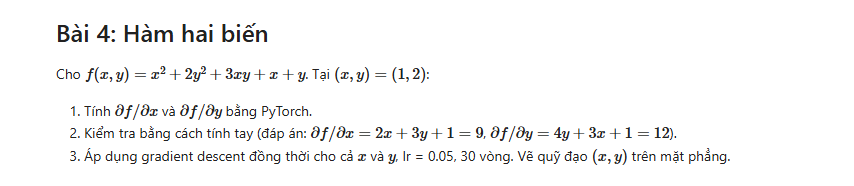

Tại (x, y) = (1, 2):
df/dx = 9.0 (Kỳ vọng: 9)
df/dy = 12.0 (Kỳ vọng: 12)

Sau 30 vòng GD, tọa độ đạt được: (-0.8134, 0.3071)


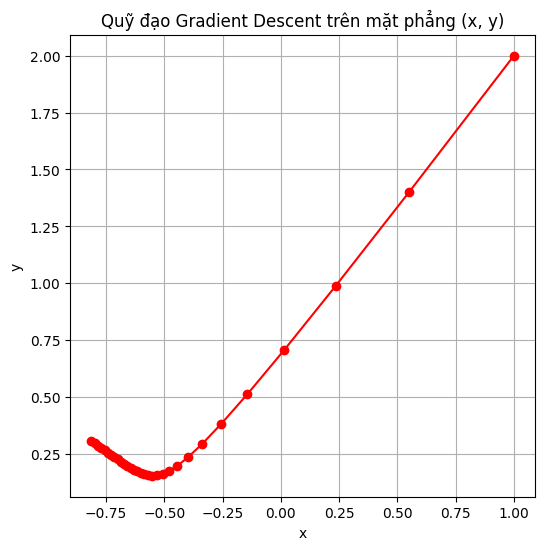

In [43]:
import torch
import matplotlib.pyplot as plt

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

f = x**2 + 2*y**2 + 3*x*y + x + y
f.backward()

print(f"Tại (x, y) = (1, 2):")
print(f"df/dx = {x.grad.item()} (Kỳ vọng: 9)")
print(f"df/dy = {y.grad.item()} (Kỳ vọng: 12)")

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
lr = 0.05
history_x, history_y = [x.item()], [y.item()]

for i in range(30):
    f_val = x**2 + 2*y**2 + 3*x*y + x + y
    f_val.backward()

    with torch.no_grad():
        x -= lr * x.grad
        y -= lr * y.grad

        x.grad.zero_()
        y.grad.zero_()

    history_x.append(x.item())
    history_y.append(y.item())

print(f"\nSau 30 vòng GD, tọa độ đạt được: ({x.item():.4f}, {y.item():.4f})")

plt.figure(figsize=(6, 6))
plt.plot(history_x, history_y, 'ro-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quỹ đạo Gradient Descent trên mặt phẳng (x, y)')
plt.grid(True)
plt.show()